In [1]:
import numpy as np
import stim
import matplotlib.pyplot as plt
import pymatching
import qsample as qs
import sys

def coords_to_numbers_data(x,y,d,w):
    number = (y-1)*(2*d+w) + (x-1)
    return number

def numbers_to_coords_data(n,d,w):
    y = n//(2*d+w) + 1
    x = n%(2*d+w) + 1
    return x,y

def numbers_to_coords_Z_measure(n,d,w):
    y = n//((2*d+w-1)//2) + 0.5
    if (y-0.5)%2 == 0:
        x = 2*(n%((2*d+w-1)//2)) + 2.5
    else:
        x = 2*(n%((2*d+w-1)//2)) + 1.5
    return x,y

def coords_to_numbers_Z_measure(x,y,d,w):
    if (y-0.5)%2 == 0:
        n = (y-0.5)*((2*d+w-1)//2) + (x-2.5)//2
    else:
        n = (y-0.5)*((2*d+w-1)//2) + (x-1.5)//2
    return int(n)

def numbers_to_coords_X_measure(n,d,w):
    y = n//((2*d+w+1)//2) + 1.5
    if (y-1.5)%2 == 0:
        x = 2*(n%((2*d+w+1)//2)) + 0.5
    else:
        x = 2*(n%((2*d+w+1)//2)) + 1.5
    return x,y

def coords_to_numbers_X_measure(x,y,d,w):
    if (y-1.5)%2 == 0:
        n = (y-1.5)*((2*d+w+1)//2) + (x-0.5)//2
    else:
        n = (y-1.5)*((2*d+w+1)//2) + (x-1.5)//2
    return int(n)

def Z_stabilizers_general(d1,d2): #d1 vertical distance, d2 horizontal distance
    Z_stabs=np.zeros((((d1+1)*(d2-1))//2,d1*d2),dtype=int)
    counter = 0
    if d1%2 == 1 and d2%2 == 1:
        for i in range((d2-1)//2):
            Z_stabs[counter,1+i*2] = 1
            Z_stabs[counter,2+2*i] = 1
            counter += 1
        for i in range(d1-1):
            for j in range((d2-1)//2):
                num = i%2
                Z_stabs[counter,num + j*2 + i*d2] = 1
                Z_stabs[counter,num + j*2 + i*d2 +1] = 1
                Z_stabs[counter,num + j*2 + (i+1)*d2] = 1
                Z_stabs[counter,num + j*2 + (i+1)*d2 +1] = 1
                counter += 1
        for i in range((d2-1)//2):
            num = (d1-1)*d2
            Z_stabs[counter,num+i*2] = 1
            Z_stabs[counter,num+1+2*i] = 1
            counter += 1
    else:
        for i in range((d2-2)//2):
            Z_stabs[counter,1+i*2] = 1
            Z_stabs[counter,2+2*i] = 1
            counter += 1
        for i in range(d1-1):
            if i%2 == 0:
                for j in range(d2//2):
                    Z_stabs[counter,j*2 + i*d2] = 1
                    Z_stabs[counter,j*2 + i*d2 +1] = 1
                    Z_stabs[counter,j*2 + (i+1)*d2] = 1
                    Z_stabs[counter,j*2 + (i+1)*d2 +1] = 1
                    counter += 1
            else:
                for j in range((d2-2)//2):
                    Z_stabs[counter,1 + j*2 + i*d2] = 1
                    Z_stabs[counter,1 + j*2 + i*d2 +1] = 1
                    Z_stabs[counter,1 + j*2 + (i+1)*d2] = 1
                    Z_stabs[counter,1 + j*2 + (i+1)*d2 +1] = 1
                counter += 1
        for i in range(d2//2):
            num = (d1-1)*d2
            Z_stabs[counter,num+i*2] = 1
            Z_stabs[counter,num+1+2*i] = 1
            counter += 1
    return Z_stabs

def X_stabilizers_general(d1,d2): #d1 vertical distance, d2 horizontal distance
    X_stabs = np.zeros((((d1-1)*(d2+1))//2,d1*d2),dtype=int)
    counter = 0
    if d1%2 == 1 and d2%2 == 1:
        step = (d2+1)//2
        for i in range((d1-1)//2):
            X_stabs[counter,(2*i)*d2] = 1
            X_stabs[counter,(2*i+1)*d2] = 1
            counter += 2*step
        counter = 1
        for j in range(d1-1):
            num1 = j*d2
            if (j+1)%2:
                num1 += 1
            for i in range((d2-1)//2):
                num2 = 2*i
                X_stabs[counter,num1 + num2 ] = 1
                X_stabs[counter,num1 + num2 + 1] = 1
                X_stabs[counter,num1 + num2 + d2 + 1] = 1
                X_stabs[counter,num1 + num2 + d2] = 1
                counter += 1
            if (j)%2:
                counter += 2
        offset = (2*d2)-1
        counter = 2*step-1
        for i in range((d1-1)//2):
            X_stabs[counter,offset+2*i*d2] = 1
            X_stabs[counter,offset+(1+2*i)*d2] = 1
            counter += 2*step
    else:
        step = d2//2
        for i in range((d1-1)//2):
            X_stabs[counter,(2*i)*d2] = 1
            X_stabs[counter,(2*i+1)*d2] = 1
            counter += 2*step + 1
        counter = 1
        for j in range(d1-1):
            num1 = j*d2
            if j%2 == 0:
                for i in range((d2-2)//2):
                    num2 = 2*i
                    X_stabs[counter,num1 + num2 + 1] = 1
                    X_stabs[counter,num1 + num2 + 2] = 1
                    X_stabs[counter,num1 + num2 + d2 + 1] = 1
                    X_stabs[counter,num1 + num2 + d2 + 2] = 1
                    counter += 1
                counter += 1
            else:
                for i in range(d2//2):
                    num2 = 2*i
                    X_stabs[counter,num1 + num2] = 1
                    X_stabs[counter,num1 + num2 + 1] = 1
                    X_stabs[counter,num1 + num2 + d2] = 1
                    X_stabs[counter,num1 + num2 + d2 + 1] = 1
                    counter += 1
                counter += 1
        offset = d2 - 1
        counter = d2//2
        for i in range((d1-1)//2):
            X_stabs[counter,offset+2*i*d2] = 1
            X_stabs[counter,offset+(1+2*i)*d2] = 1
            counter += 2*step + 1
    return X_stabs

def create_surface_code_patch(top_left,top_right,bottom_left,bottom_right,d,w):
    number_of_data_qubits = 2*(d**2) + w*d
    number_of_ancillas_Z = (2*d+w-1)*(d+1)//2
    number_of_ancillas_X = (d-1)*(2*d+w+1)//2
    Z_stabilizers = np.zeros((number_of_ancillas_Z,number_of_data_qubits),dtype = int)
    X_stabilizers = np.zeros((number_of_ancillas_X,number_of_data_qubits),dtype = int)
    d1 = int(bottom_left[1]-top_left[1]+1) #vertical code distance
    d2 = int(top_right[0]-top_left[0]+1) #horizontal code distance
    Z_stabs = Z_stabilizers_general(d1,d2)
    X_stabs = X_stabilizers_general(d1,d2)
    
    if d1%2 == 1 and d2%2 == 1:
        data_counter = 0
        for k in range(d1):
            for l in range(d2):
                coords = top_left + np.array([l,k])
                Z_counter = 0
                for j in range(d1+1):
                    for i in range((d2-1)//2):
                        if j%2 == 0:
                            Z_coords = top_left + np.array([1.5+2*i,-0.5+j])
                        else:
                            Z_coords = top_left + np.array([0.5+2*i,-0.5+j])
                        if Z_stabs[Z_counter,data_counter] == 1:
                            Z_stabilizers[coords_to_numbers_Z_measure(Z_coords[0],Z_coords[1],d,w),coords_to_numbers_data(coords[0],coords[1],d,w)] = 1
                        Z_counter += 1
                X_counter = 0
                for j in range(d1-1):
                    for i in range((d2+1)//2):
                        if j%2 == 0:
                            X_coords = top_left + np.array([-0.5 + 2*i, 0.5 + j])
                        else:
                            X_coords = top_left + np.array([0.5 + 2*i, 0.5 + j])
                        if X_stabs[X_counter,data_counter] == 1:
                            X_stabilizers[coords_to_numbers_X_measure(X_coords[0],X_coords[1],d,w),coords_to_numbers_data(coords[0],coords[1],d,w)] = 1
                        X_counter += 1
                data_counter += 1

    else:
        data_counter = 0
        for k in range(d1):
            for l in range(d2):
                coords = top_left + np.array([l,k])
                Z_counter = 0
                for j in range(d1+1):
                    if j%2 == 0:
                        for i in range((d2-2)//2):
                            Z_coords = top_left + np.array([1.5+2*i,-0.5+j])
                            if Z_stabs[Z_counter,data_counter] == 1:
                                Z_stabilizers[coords_to_numbers_Z_measure(Z_coords[0],Z_coords[1],d,w),coords_to_numbers_data(coords[0],coords[1],d,w)] = 1
                            Z_counter += 1
                    else:
                        for i in range(d2//2):
                            Z_coords = top_left + np.array([0.5+2*i,-0.5+j])
                            if Z_stabs[Z_counter,data_counter] == 1:
                                Z_stabilizers[coords_to_numbers_Z_measure(Z_coords[0],Z_coords[1],d,w),coords_to_numbers_data(coords[0],coords[1],d,w)] = 1
                            Z_counter += 1
                X_counter = 0
                for j in range(d1-1):
                    if j%2 == 0:
                        for i in range((d2+2)//2):
                            X_coords = top_left + np.array([-0.5 + 2*i, 0.5 + j])
                            if X_stabs[X_counter,data_counter] == 1:
                                X_stabilizers[coords_to_numbers_X_measure(X_coords[0],X_coords[1],d,w),coords_to_numbers_data(coords[0],coords[1],d,w)] = 1
                            X_counter += 1
                    else:
                        for i in range(d2//2):
                            X_coords = top_left + np.array([0.5 + 2*i, 0.5 + j])
                            if X_stabs[X_counter,data_counter] == 1:
                                X_stabilizers[coords_to_numbers_X_measure(X_coords[0],X_coords[1],d,w),coords_to_numbers_data(coords[0],coords[1],d,w)] = 1
                            X_counter += 1
                data_counter += 1
    
    return X_stabilizers, Z_stabilizers

def create_teleportation_0_circuit(d,w,h1,h2,h3,p_patch,p_mid):
    
    #Creating qubit numbers and qubit indecies
    number_of_data_qubits = 2*d**2 + w*d
    number_of_ancillas_Z = (2*d+w-1)*(d+1)//2
    number_of_ancillas_X = (d-1)*(2*d+w+1)//2
    data_qubits = np.arange(0,number_of_data_qubits,dtype = int)
    X_measure_qubits = np.arange(number_of_data_qubits,number_of_data_qubits + number_of_ancillas_X, dtype = int)
    Z_measure_qubits = np.arange(number_of_data_qubits + number_of_ancillas_X, number_of_data_qubits + number_of_ancillas_X + number_of_ancillas_Z, dtype = int)

    #Creating stabilizers for patch1, patch2, and for the merged patch
    X_stabilizers1, Z_stabilizers1 = create_surface_code_patch(np.array([1,1]),np.array([d,1]),np.array([1,d]),np.array([d,d]),d,w)
    X_stabilizers2, Z_stabilizers2 = create_surface_code_patch(np.array([d+w+1,1]),np.array([2*d+w,1]),np.array([d+w+1,d]),np.array([2*d+w,d]),d,w)
    X_stabilizers3, Z_stabilizers3 = create_surface_code_patch(np.array([1,1]),np.array([2*d+w,1]),np.array([1,d]),np.array([2*d+w,d]),d,w)
    X_empty, Z_empty = create_surface_code_patch(np.array([1,1]),np.array([1,1]),np.array([1,1]),np.array([1,1]),d,w)
    X_mid, Z_mid = create_surface_code_patch(np.array([d,1]),np.array([d+w+1,1]),np.array([d,d]),np.array([d+w+1,d]),d,w)
    X_left, Z_left = create_surface_code_patch(np.array([1,1]),np.array([d+w,1]),np.array([1,d]),np.array([d+w,d]),d,w)

    
    #Determining the order of CNOTs for stabilizer measurements
    rotated_Z_shape = [0,1,2,3]
    rotated_X_shape = [0,2,1,3]

    #Creating arrays for storing the indecies of the measurments for each ancilla qubit and a measurement counter
    X_measurement_values = [None]*number_of_ancillas_X
    Z_measurement_values = [None]*number_of_ancillas_Z
    measurement_counter = 0

    #Logical observable
    Logical_X = []

    #Creating inhomogenous error distribution
    p_data = np.zeros(number_of_data_qubits)
    p_X_measure = np.zeros(number_of_ancillas_X)
    p_Z_measure = np.zeros(number_of_ancillas_Z)

    for i in range(number_of_data_qubits):
        coords = numbers_to_coords_data(i,d,w)
        if coords[0] > d and coords[0] < d+w+1:
            p_data[i] = p_mid
        else:
            p_data[i] = p_patch

    for i in range(number_of_ancillas_Z):
        coords = numbers_to_coords_Z_measure(i,d,w)
        if coords[0] > d and coords[0] < d+w+1:
            p_Z_measure[i] = p_mid
        else:
            p_Z_measure[i] = p_patch

    for i in range(number_of_ancillas_X):
        coords = numbers_to_coords_X_measure(i,d,w)
        if coords[0] > d+1 and coords[0] < d+w:
            p_X_measure[i] = p_mid
        else:
            p_X_measure[i] = p_patch

    full_circuit = stim.Circuit()

    #Creating coordinates for the qubits
    for i in range(number_of_data_qubits):
        full_circuit.append("QUBIT_COORDS",data_qubits[i],(numbers_to_coords_data(i,d,w)))
    for i in range(number_of_ancillas_X):
        full_circuit.append("QUBIT_COORDS",X_measure_qubits[i],(numbers_to_coords_X_measure(i,d,w)))
    for i in range(number_of_ancillas_Z):
        full_circuit.append("QUBIT_COORDS",Z_measure_qubits[i],(numbers_to_coords_Z_measure(i,d,w)))

    """
    Fault tolerant initialization of |++> and additional stabilizer measurment rounds
    """

    #Initializing qubits
    for i in range(number_of_data_qubits):
        full_circuit.append('R',data_qubits[i])
        full_circuit.append('X_ERROR',data_qubits[i],p_data[i])
        full_circuit.append('H',data_qubits[i])
        full_circuit.append('DEPOLARIZE1',data_qubits[i],p_data[i])
    for i in range(number_of_ancillas_X):
        full_circuit.append('R',X_measure_qubits[i])
        full_circuit.append('X_ERROR',X_measure_qubits[i],p_X_measure[i])
    for i in range(number_of_ancillas_Z):
        full_circuit.append('R',Z_measure_qubits[i])
        full_circuit.append('X_ERROR',Z_measure_qubits[i],p_Z_measure[i])

    #Choosing stabilizers
    X_stabilizers = X_stabilizers1 + X_empty
    Z_stabilizers = Z_stabilizers1 + Z_empty

    #Creating h1 stabilizer measurement rounds
    for round_counter in range(h1): 
        circuit = stim.Circuit()

        for i in range(number_of_ancillas_X):
            if np.sum(X_stabilizers[i,:]) > 0:
                circuit.append("H",X_measure_qubits[i])
                circuit.append("DEPOLARIZE1",X_measure_qubits[i],p_X_measure[i])
        circuit.append("TICK")

        #Connecting CNOT gates
        for i in range(4):
                for j in range(number_of_ancillas_X):
                    if np.sum(X_stabilizers[j,:]) == 4:
                        circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]])
                        #ERROR
                        if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][rotated_X_shape[i]] == p_mid:
                            circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]],p_mid)
                        else:
                            circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]],p_patch)

                    elif np.sum(X_stabilizers[j,:]) == 2:
                        data_coord = numbers_to_coords_data(data_qubits[X_stabilizers[j,:] == 1][i%2],d,w)
                        ancilla_coord = numbers_to_coords_X_measure(j,d,w)
                        if (data_coord[0] > ancilla_coord[0]) and (i == 2 or i == 3): #left X
                            circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:]==1][i-2]])
                            #ERROR
                            if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][i-2] == p_mid:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i-2]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i-2]],p_patch)

                        elif (data_coord[0] < ancilla_coord[0]) and (i == 0 or i == 1): #right X
                            circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:]==1][i]])
                            #ERROR
                            if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][i] == p_mid:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i]],p_patch)

                for j in range(number_of_ancillas_Z):
                    if np.sum(Z_stabilizers[j,:])==4:
                        circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]])
                        #ERROR
                        if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][rotated_Z_shape[i]] == p_mid:
                            circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]],p_mid)
                        else:
                            circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]],p_patch)

                    elif np.sum(Z_stabilizers[j,:]) == 2:
                        data_coord = numbers_to_coords_data(data_qubits[Z_stabilizers[j,:] == 1][i%2],d,w)
                        ancilla_coord = numbers_to_coords_Z_measure(j,d,w)
                        if (data_coord[1] > ancilla_coord[1]) and (i == 2 or i == 3): #top Z
                            circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]])
                            #ERROR
                            if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][i-2] == p_mid:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]],p_patch)

                        elif (data_coord[1] < ancilla_coord[1]) and (i == 0 or i == 1): #bottom Z
                            circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]])
                            #ERROR
                            if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][i] == p_mid:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]],p_patch)

                circuit.append("TICK")

        for i in range(number_of_ancillas_X):
            if np.sum(X_stabilizers[i,:]) > 0:
                circuit.append("H",X_measure_qubits[i])
                circuit.append("DEPOLARIZE1",X_measure_qubits[i],p_X_measure[i])

        #Inserting measurments and detectors for the first round
        if round_counter == 0:
            for i in range(number_of_ancillas_X):
                coords = numbers_to_coords_X_measure(i,d,w)
                if np.sum(X_stabilizers[i,:]) > 0:
                    circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("R",X_measure_qubits[i])
                    circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1)])
                    X_measurement_values[i] = measurement_counter
                    measurement_counter += 1
            for i in range(number_of_ancillas_Z):
                coords = numbers_to_coords_Z_measure(i,d,w)
                if np.sum(Z_stabilizers[i,:]) > 0:
                    circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("R",Z_measure_qubits[i])
                    circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                    Z_measurement_values[i] = measurement_counter
                    measurement_counter += 1
        
        #Inserting measurments and detectors for latter rounds
        else:
            for i in range(number_of_ancillas_X):
                coords = numbers_to_coords_X_measure(i,d,w)
                if np.sum(X_stabilizers[i,:]) > 0:
                    circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("R",X_measure_qubits[i])
                    circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + X_measurement_values[i])])
                    X_measurement_values[i] = measurement_counter
                    measurement_counter += 1
            for i in range(number_of_ancillas_Z):
                coords = numbers_to_coords_Z_measure(i,d,w)
                if np.sum(Z_stabilizers[i,:]) > 0:
                    circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("R",Z_measure_qubits[i])
                    circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + Z_measurement_values[i])])
                    Z_measurement_values[i] = measurement_counter
                    measurement_counter += 1

        full_circuit += circuit

    """
    Merging and splitting the two patches
    """

    #Initializing coupling qubits for ZZ measurement
    for j in range(d):
        for i in range(w):
            coords = np.array([d+1 + i, 1 + j])
            full_circuit.append("R",data_qubits[coords_to_numbers_data(coords[0],coords[1],d,w)])
            full_circuit.append("X_ERROR",data_qubits[coords_to_numbers_data(coords[0],coords[1],d,w)],p_data[coords_to_numbers_data(coords[0],coords[1],d,w)])
            full_circuit.append("H",data_qubits[coords_to_numbers_data(coords[0],coords[1],d,w)])
            full_circuit.append("DEPOLARIZE1",data_qubits[coords_to_numbers_data(coords[0],coords[1],d,w)],p_data[coords_to_numbers_data(coords[0],coords[1],d,w)])

    #Choosing stabilizers
    X_stabilizers = X_stabilizers3
    Z_stabilizers = Z_stabilizers3
    
    for round_counter in range(h2):
        circuit = stim.Circuit()

        for i in range(number_of_ancillas_X):
            if np.sum(X_stabilizers[i,:]) > 0:
                circuit.append("H",X_measure_qubits[i])
                circuit.append("DEPOLARIZE1",X_measure_qubits[i],p_X_measure[i])
        circuit.append("TICK")

        #Connecting CNOT gates
        for i in range(4):
                for j in range(number_of_ancillas_X):
                    if np.sum(X_stabilizers[j,:]) == 4:
                        circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]])
                        #ERROR
                        if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][rotated_X_shape[i]] == p_mid:
                            circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]],p_mid)
                        else:
                            circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]],p_patch)

                    elif np.sum(X_stabilizers[j,:]) == 2:
                        data_coord = numbers_to_coords_data(data_qubits[X_stabilizers[j,:] == 1][i%2],d,w)
                        ancilla_coord = numbers_to_coords_X_measure(j,d,w)
                        if (data_coord[0] > ancilla_coord[0]) and (i == 2 or i == 3): #left X
                            circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:]==1][i-2]])
                            #ERROR
                            if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][i-2] == p_mid:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i-2]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i-2]],p_patch)

                        elif (data_coord[0] < ancilla_coord[0]) and (i == 0 or i == 1): #right X
                            circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:]==1][i]])
                            #ERROR
                            if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][i] == p_mid:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i]],p_patch)

                for j in range(number_of_ancillas_Z):
                    if np.sum(Z_stabilizers[j,:])==4:
                        circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]])
                        #ERROR
                        if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][rotated_Z_shape[i]] == p_mid:
                            circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]],p_mid)
                        else:
                            circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]],p_patch)

                    elif np.sum(Z_stabilizers[j,:]) == 2:
                        data_coord = numbers_to_coords_data(data_qubits[Z_stabilizers[j,:] == 1][i%2],d,w)
                        ancilla_coord = numbers_to_coords_Z_measure(j,d,w)
                        if (data_coord[1] > ancilla_coord[1]) and (i == 2 or i == 3): #top Z
                            circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]])
                            #ERROR
                            if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][i-2] == p_mid:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]],p_patch)

                        elif (data_coord[1] < ancilla_coord[1]) and (i == 0 or i == 1): #bottom Z
                            circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]])
                            #ERROR
                            if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][i] == p_mid:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]],p_patch)

                circuit.append("TICK")

        for i in range(number_of_ancillas_X):
            if np.sum(X_stabilizers[i,:]) > 0:
                circuit.append("H",X_measure_qubits[i])
                circuit.append("DEPOLARIZE1",X_measure_qubits[i],p_X_measure[i])

        #Inserting measurements and detectors for the first round
        if round_counter == 0:
            for i in range(number_of_ancillas_X):
                X_coords = numbers_to_coords_X_measure(i,d,w)
                if np.sum(X_stabilizers[i,:]) > 0:
                    if X_coords[0] > d+1:
                        circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                        circuit.append("R",X_measure_qubits[i])
                        circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                        circuit.append("DETECTOR",[stim.target_rec(-1)])
                    else:
                        circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                        circuit.append("R",X_measure_qubits[i])
                        circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                        circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + X_measurement_values[i])])
                    X_measurement_values[i] = measurement_counter
                    measurement_counter += 1

            for i in range(number_of_ancillas_Z):
                Z_coords = numbers_to_coords_Z_measure(i,d,w)
                if np.sum(Z_stabilizers[i,:]) > 0:
                    if Z_coords[0] > d:
                        circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                        circuit.append("R",Z_measure_qubits[i])
                        circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                    else:
                        circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                        circuit.append("R",Z_measure_qubits[i])
                        circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                        circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + Z_measurement_values[i])])
                    Z_measurement_values[i] = measurement_counter
                    measurement_counter += 1

        #Inserting measurements and detectors for latter rounds
        else:
            for i in range(number_of_ancillas_X):
                coords = numbers_to_coords_X_measure(i,d,w)
                if np.sum(X_stabilizers[i,:]) > 0:
                    if coords[0] > d+1 and coords[0] < d+w:
                        circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                        circuit.append("R",X_measure_qubits[i])
                        circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                    else:
                        circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                        circuit.append("R",X_measure_qubits[i])
                        circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + X_measurement_values[i])])
                    X_measurement_values[i] = measurement_counter
                    measurement_counter += 1
            for i in range(number_of_ancillas_Z):
                coords = numbers_to_coords_Z_measure(i,d,w)
                if np.sum(Z_stabilizers[i,:]) > 0:
                    if coords[0] > d and coords[0] < d+w+1:
                        circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                        circuit.append("R",Z_measure_qubits[i])
                        circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                    else:
                        circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                        circuit.append("R",Z_measure_qubits[i])
                        circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + Z_measurement_values[i])])
                    Z_measurement_values[i] = measurement_counter
                    measurement_counter += 1

        full_circuit += circuit

    #Measuring coupling qubits and data qubits of the left
    X_data_measurement_values = [[] for i in range(number_of_ancillas_X)]
    measured_datas = []
    measured_values = []
    for i in range(number_of_ancillas_X):
        data_indices = np.argwhere(X_stabilizers[i,:] == 1)[:,0]
        for index in data_indices:
            coords = numbers_to_coords_data(index,d,w)
            if coords[0] < d+w+1:
                if index in measured_datas:
                    X_data_measurement_values[i].append(measured_values[measured_datas.index(index)])
                else:
                    full_circuit.append("H",data_qubits[index])
                    full_circuit.append("DEPOLARIZE1",data_qubits[index],p_data[index])
                    full_circuit.append("M",data_qubits[index],p_data[index])
                    if coords[1] == 1:
                        Logical_X.append(measurement_counter)
                    X_data_measurement_values[i].append(measurement_counter)
                    measured_datas.append(index)
                    measured_values.append(measurement_counter)
                    measurement_counter += 1
    
    """
    Additional measurement rounds and fault tolerant measurements of X2
    """

    #Choosing the stabilizer
    X_stabilizers = X_empty + X_stabilizers2
    Z_stabilizers = Z_empty + Z_stabilizers2

    for round_counter in range(h3):
        circuit = stim.Circuit()

        for i in range(number_of_ancillas_X):
            if np.sum(X_stabilizers[i,:]) > 0:
                circuit.append("H",X_measure_qubits[i])
                circuit.append("DEPOLARIZE1",X_measure_qubits[i],p_X_measure[i])
        circuit.append("TICK")

        #Connecting CNOT gates
        for i in range(4):
                for j in range(number_of_ancillas_X):
                    if np.sum(X_stabilizers[j,:]) == 4:
                        circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]])
                        #ERROR
                        if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][rotated_X_shape[i]] == p_mid:
                            circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]],p_mid)
                        else:
                            circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][rotated_X_shape[i]]],p_patch)

                    elif np.sum(X_stabilizers[j,:]) == 2:
                        data_coord = numbers_to_coords_data(data_qubits[X_stabilizers[j,:] == 1][i%2],d,w)
                        ancilla_coord = numbers_to_coords_X_measure(j,d,w)
                        if (data_coord[0] > ancilla_coord[0]) and (i == 2 or i == 3): #left X
                            circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:]==1][i-2]])
                            #ERROR
                            if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][i-2] == p_mid:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i-2]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i-2]],p_patch)

                        elif (data_coord[0] < ancilla_coord[0]) and (i == 0 or i == 1): #right X
                            circuit.append("CNOT", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:]==1][i]])
                            #ERROR
                            if p_X_measure[j] == p_mid or p_data[X_stabilizers[j,:] == 1][i] == p_mid:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [X_measure_qubits[j],data_qubits[X_stabilizers[j,:] == 1][i]],p_patch)

                for j in range(number_of_ancillas_Z):
                    if np.sum(Z_stabilizers[j,:])==4:
                        circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]])
                        #ERROR
                        if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][rotated_Z_shape[i]] == p_mid:
                            circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]],p_mid)
                        else:
                            circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][rotated_Z_shape[i]],Z_measure_qubits[j]],p_patch)

                    elif np.sum(Z_stabilizers[j,:]) == 2:
                        data_coord = numbers_to_coords_data(data_qubits[Z_stabilizers[j,:] == 1][i%2],d,w)
                        ancilla_coord = numbers_to_coords_Z_measure(j,d,w)
                        if (data_coord[1] > ancilla_coord[1]) and (i == 2 or i == 3): #top Z
                            circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]])
                            #ERROR
                            if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][i-2] == p_mid:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i-2],Z_measure_qubits[j]],p_patch)

                        elif (data_coord[1] < ancilla_coord[1]) and (i == 0 or i == 1): #bottom Z
                            circuit.append("CNOT", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]])
                            #ERROR
                            if p_Z_measure[j] == p_mid or p_data[Z_stabilizers[j,:]==1][i] == p_mid:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]],p_mid)
                            else:
                                circuit.append("DEPOLARIZE2", [data_qubits[Z_stabilizers[j,:]==1][i],Z_measure_qubits[j]],p_patch)

                circuit.append("TICK")

        for i in range(number_of_ancillas_X):
            if np.sum(X_stabilizers[i,:]) > 0:
                circuit.append("H",X_measure_qubits[i])
                circuit.append("DEPOLARIZE1",X_measure_qubits[i],p_X_measure[i])

        #Inserting measurements and detectors for the first round
        if round_counter == 0:
            for i in range(number_of_ancillas_X):
                X_coords = numbers_to_coords_X_measure(i,d,w)
                if len(X_data_measurement_values[i]) > 0 and np.sum(X_stabilizers[i,:]) == 0:
                    target_records = []
                    for number in X_data_measurement_values[i]:
                        target_records.append(stim.target_rec( - measurement_counter + number))
                    circuit.append("DETECTOR",target_records + [stim.target_rec( - measurement_counter + X_measurement_values[i])])
                elif np.sum(X_stabilizers[i,:]) > 0 and len(X_data_measurement_values[i]) > 0:
                    target_records = []
                    for number in X_data_measurement_values[i]:
                        target_records.append(stim.target_rec(-1 - measurement_counter + number))
                    circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("R",X_measure_qubits[i])
                    circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + X_measurement_values[i])] + target_records)
                    X_measurement_values[i] = measurement_counter
                    measurement_counter += 1
                elif np.sum(X_stabilizers[i,:]) > 0 and len(X_data_measurement_values[i]) == 0:
                    circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("R",X_measure_qubits[i])
                    circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + X_measurement_values[i])])
                    X_measurement_values[i] = measurement_counter
                    measurement_counter += 1
                
            for i in range(number_of_ancillas_Z):
                Z_coords = numbers_to_coords_Z_measure(i,d,w)
                if np.sum(Z_stabilizers[i,:]) > 0:
                    circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("R",Z_measure_qubits[i])
                    circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + Z_measurement_values[i])])
                    Z_measurement_values[i] = measurement_counter
                    measurement_counter += 1

        #Inserting measurements and detectors for latter rounds
        else:
            for i in range(number_of_ancillas_X):
                if np.sum(X_stabilizers[i,:]) > 0:
                    circuit.append("M",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("R",X_measure_qubits[i])
                    circuit.append("X_ERROR",X_measure_qubits[i],p_X_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + X_measurement_values[i])])
                    X_measurement_values[i] = measurement_counter
                    measurement_counter += 1
            for i in range(number_of_ancillas_Z):
                if np.sum(Z_stabilizers[i,:]) > 0:
                    circuit.append("M",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("R",Z_measure_qubits[i])
                    circuit.append("X_ERROR",Z_measure_qubits[i],p_Z_measure[i])
                    circuit.append("DETECTOR",[stim.target_rec(-1),stim.target_rec(-1 - measurement_counter + Z_measurement_values[i])])
                    Z_measurement_values[i] = measurement_counter
                    measurement_counter += 1

        full_circuit += circuit

    #Measuring the data qubits and constructing detectors and logical observables
    X_data_measurement_values = [[] for i in range(number_of_ancillas_X)]
    measured_datas = []
    measured_values = []
    for i in range(number_of_ancillas_X):
        data_indices = np.argwhere(X_stabilizers2[i,:] == 1)[:,0]
        for index in data_indices:
            coords = numbers_to_coords_data(index,d,w)
            if index in measured_datas:
                X_data_measurement_values[i].append(measured_values[measured_datas.index(index)])
            else:
                full_circuit.append('H',data_qubits[index])
                full_circuit.append('DEPOLARIZE1',data_qubits[index],p_data[index])
                full_circuit.append("M",data_qubits[index],p_data[index])
                #Logical observables
                if coords[1] == 1:
                    Logical_X.append(measurement_counter)
                X_data_measurement_values[i].append(measurement_counter)
                measured_datas.append(index)
                measured_values.append(measurement_counter)
                measurement_counter += 1

    for i in range(number_of_ancillas_X):
        if len(X_data_measurement_values[i]) > 0:
            target_records = []
            for number in X_data_measurement_values[i]:
                target_records.append(stim.target_rec( - measurement_counter + number))
            full_circuit.append("DETECTOR",target_records + [stim.target_rec( - measurement_counter + X_measurement_values[i])])

    #Includeing logical observables
    observable = []
    for number in Logical_X:
        observable.append(stim.target_rec( - measurement_counter + number))
    
    full_circuit.append("OBSERVABLE_INCLUDE",observable,0)
    
    return full_circuit

def count_logical_errors(circuit: stim.Circuit, num_shots: int):
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    #detector_error_model = circuit.detector_error_model(decompose_errors=False)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        #print(actual_for_shot,predicted_for_shot)
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors

d = 3
h1 = 1
h2 = 3
h3 = 1
w = 1
p_patch = 0.0085
p_mid = 0.0085
sim = 10000

nparams = int((len(sys.argv)-1)/2)
for nparam in range(nparams):
    if sys.argv[1+nparam*2] == '-d':
        print('#Code distance: ',sys.argv[2+nparam*2])
        d = int(sys.argv[2+nparam*2])
    if sys.argv[1+nparam*2] == '-h1':
        print('#h1 measurement rounds: ',sys.argv[2+nparam*2])
        h1 = int(sys.argv[2+nparam*2])
    if sys.argv[1+nparam*2] == '-h2':
        print('#h2 measurement rounds: ',sys.argv[2+nparam*2])
        h2 = int(sys.argv[2+nparam*2])
    if sys.argv[1+nparam*2] == '-h3':
        print('#h3 measurement rounds: ',sys.argv[2+nparam*2])
        h3 = int(sys.argv[2+nparam*2])
    if sys.argv[1+nparam*2] == '-w':
        print('#Width of the middle region: ',sys.argv[2+nparam*2])
        w = int(sys.argv[2+nparam*2])
    if sys.argv[1+nparam*2] == '-p_p':
        print('#Error scaling factor: ',sys.argv[2+nparam*2])
        p_patch = float(sys.argv[2+nparam*2])
    if sys.argv[1+nparam*2] == '-p_m':
        print('#Error scaling factor: ',sys.argv[2+nparam*2])
        p_mid = float(sys.argv[2+nparam*2])
    if sys.argv[1+nparam*2] == '-sim':
        print('#Number of simulation rounds: ',sys.argv[2+nparam*2])
        sim = int(sys.argv[2+nparam*2])

teleport_circuit = create_teleportation_0_circuit(d,w,h1,h2,h3,p_patch,p_mid)
#err = count_logical_errors(teleport_circuit,sim)

#print('#number of total errors')
#print(err)

/Users/jhfontes/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[[0], [1], [2], [3], [0, 0], [1, 1], [10], [11], [2, 2], [3, 3], [14], [15], [4, 4], [5, 5], [6, 6], [7, 7], [0, 0], [1, 1], [10, 10], [11, 11], [2, 2], [3, 3], [14, 14], [15, 15], [4, 4], [17, 17], [18, 18], [5, 5], [20, 20], [21, 21], [6, 6], [23, 23], [24, 24], [7, 7], [26, 26], [27, 27], [0, 0], [1, 1], [10, 10], [11, 11], [2, 2], [3, 3], [14, 14], [15, 15], [4, 4], [17, 17], [18, 18], [5, 5], [20, 20], [21, 21], [6, 6], [23, 23], [24, 24], [7, 7], [26, 26], [27, 27], [68, 69, 0], [70, 71, 72, 73, 1], [10, 10, 74, 75], [11, 11], [69, 72, 76, 77, 2], [73, 75, 78, 79, 3], [14, 14], [15, 15], [18, 18], [21, 21], [24, 24], [27, 27], [88, 89, 10], [90, 91, 92, 93, 11], [89, 92, 94, 95, 14], [93, 96, 15]]
[[68, 70, 71, 74, 88, 90, 91]]


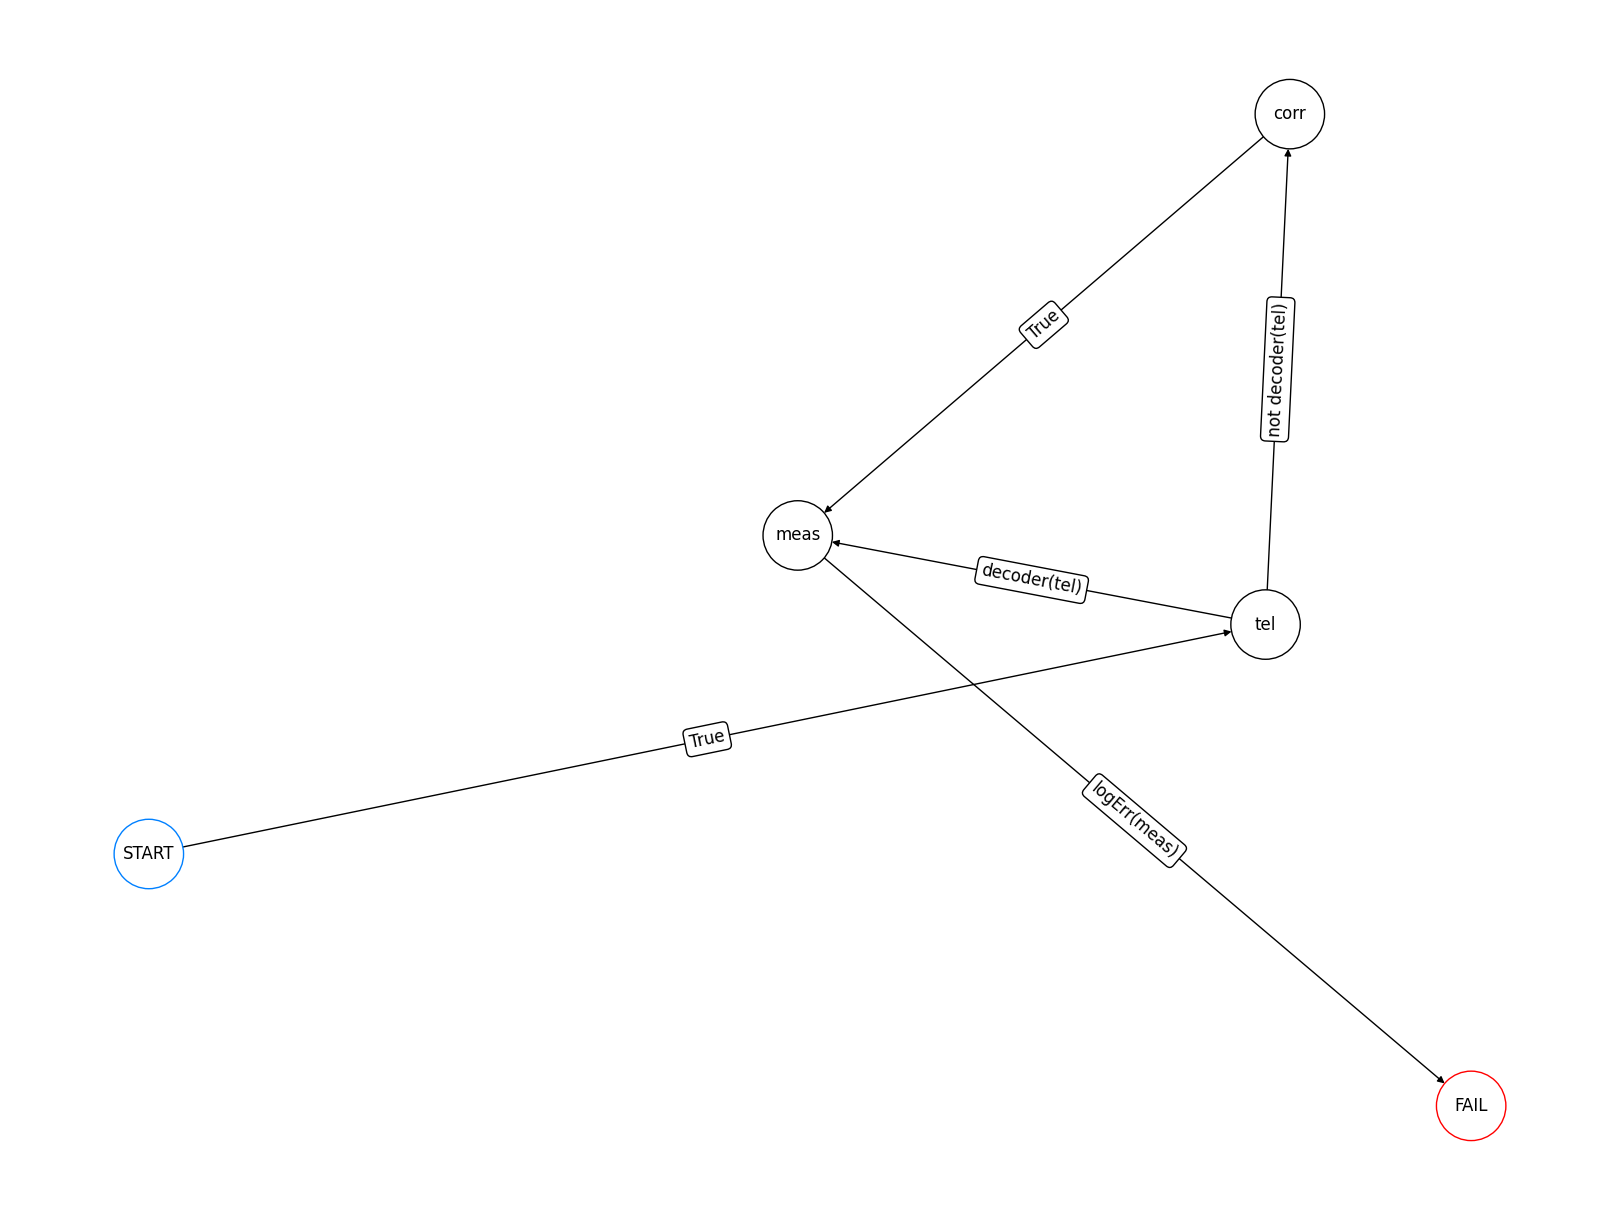

In [ ]:
# TO DO: VERIFY CORR, VERIFY LOGERR

tel = qs.Circuit(noisy=True)
tel.from_stim_circuit(teleport_circuit)

matching = pymatching.Matching(tel.dem)

num_detectors = matching.num_detectors
detector_array = tel.detector_array
print(detector_array)
observable_array = tel.observable_array
print(observable_array)
meas_str = ""
for i in observable_array[0]:
    meas_str+=str(i)
    meas_str+=" "

corr = qs.Circuit(noisy=False).from_stim_circuit("""X """+meas_str)
meas = qs.Circuit(noisy=False).from_stim_circuit("""M """+meas_str)


def int2meas(out):
    result = []
    for i in np.arange(tel.n_measurements)[::-1]:
        result.append(out//(2**int(i)))
        out-=result[-1]*2**int(i)
    return result

def measurement2detector(out, detector_array):
    out = int2meas(out[-1])
    detection_events = np.zeros(num_detectors)
    for ii in range(num_detectors):
        event = 0
        for jj in detector_array[ii]:
            event^=int(out[jj])
        detection_events[ii]=event
    return detection_events
    
def decoder(out):
    detection_events = measurement2detector(out, detector_array)
    result = matching.decode(detection_events)
    return result

def logErr(out):
    meas_1 = 0
    for i in range(distance):
        j = (out[0]>=(2**(distance-1-i)))
        meas_1+=j
        out[0]-=2**(distance-1-i)*j
    return meas_1%2

functions = {'decoder': decoder, 'matching':matching, 'logErr':logErr,}
ls = qs.Protocol(check_functions=functions)


n_rounds = 1
ls.add_nodes_from(['tel', 'corr', 'meas'], circuits=[tel, corr, meas])
ls.add_edge('START', 'tel', check='True')
ls.add_edge('tel', 'meas', check='decoder(tel)')
ls.add_edge('tel', 'corr', check='not decoder(tel)')
ls.add_edge('corr', 'meas', check='True')
ls.add_edge('meas', 'FAIL', check='logErr(meas)')

ls.draw(figsize=(16,12), path='protocol_lattice')

In [5]:
d = 3
h1 = 1
h2 = 3
h3 = 1
w = 1
p_patch = 0.0085
p_mid = 0.0085
sim = 10000

p = np.zeros(8)
lerror = np.zeros((3,8))
for i in range(3):
    d = 3+4*i
    h2 = 3+4*i
    w = 1
    for j in range(8):
        p[j] = 0.065+0.0025*j
        p_patch = 0
        p_mid = p[j]
        teleport_circuit = create_teleportation_0_circuit(d,w,h1,h2,h3,p_patch,p_mid)
        err = count_logical_errors(teleport_circuit,sim)
        lerror[i,j] = err
        print(i,j,err)

0 0 2693
0 1 2925
0 2 2915
0 3 2970
0 4 3170
0 5 3321
0 6 3341
0 7 3490
1 0 2478


KeyboardInterrupt: 

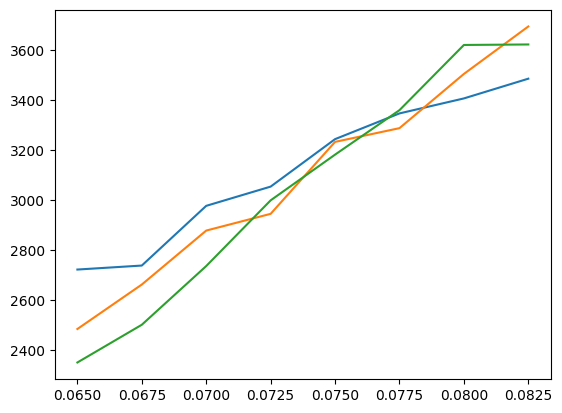

In [6]:
for i in range(3):
    plt.plot(p,lerror[i,:])